# Exploratory Data Analysis (EDA) Khusus

Notebook ini dibuat khusus untuk menjalankan langkah-langkah EDA tambahan guna menjawab permasalahan bisnis secara lebih rinci.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

In [2]:
# Memuat dataset
data = pd.read_csv('dataset/employee_data.csv')
data.head()

,EmployeeId,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,1,38,NaN,Travel_Frequently,1444,Human Resources,1,4,Other,1,...,2,80,1,7,2,3,6,2,1,2
1,2,37,1.0,Travel_Rarely,1141,Research & Development,11,2,Medical,1,...,1,80,0,15,2,1,1,0,0,0
2,3,51,1.0,Travel_Rarely,1323,Research & Development,4,4,Life Sciences,1,...,3,80,3,18,2,4,10,0,2,7
3,4,42,0.0,Travel_Frequently,555,Sales,26,3,Marketing,1,...,4,80,1,23,2,4,20,4,4,8
4,5,40,NaN,Travel_Rarely,1194,Research & Development,2,4,Medical,1,...,2,80,3,20,2,3,5,3,0,2


## Menjawab Permasalahan Bisnis 1: Identifikasi Faktor Utama
Kita akan mengeksplorasi hubungan *Attrition* dengan faktor kompensasi finansial (Monthly Income) dan kepuasan kerja (Job Satisfaction & Environment Satisfaction).

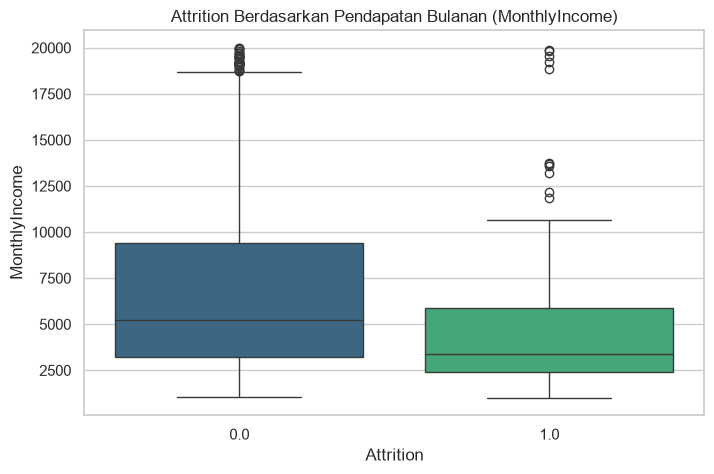

In [3]:
# Kompensasi: Hubungan Attrition dengan MonthlyIncome
plt.figure(figsize=(8,5))
sns.boxplot(data=data, x='Attrition', y='MonthlyIncome', palette='viridis')
plt.title('Attrition Berdasarkan Pendapatan Bulanan (MonthlyIncome)')
plt.show()

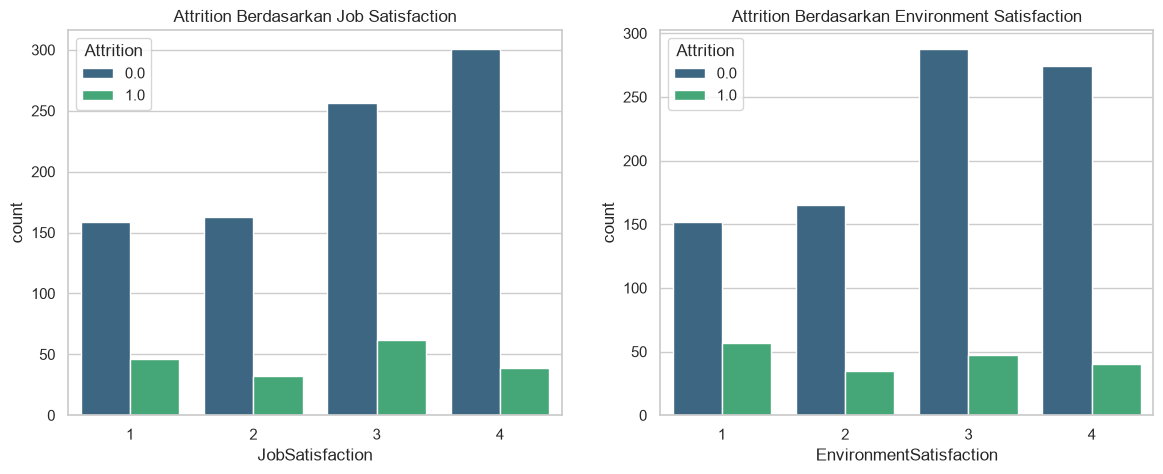

In [4]:
# Kepuasan Kerja: Hubungan Attrition dengan JobSatisfaction & EnvironmentSatisfaction
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.countplot(data=data, x='JobSatisfaction', hue='Attrition', palette='viridis', ax=axes[0])
axes[0].set_title('Attrition Berdasarkan Job Satisfaction')
sns.countplot(data=data, x='EnvironmentSatisfaction', hue='Attrition', palette='viridis', ax=axes[1])
axes[1].set_title('Attrition Berdasarkan Environment Satisfaction')
plt.show()

## Menjawab Permasalahan Bisnis 2: Analisis Perilaku Karyawan
Fokus pada pengaruh jarak tempuh rumah ke kantor terhadap tingkat *Attrition*.

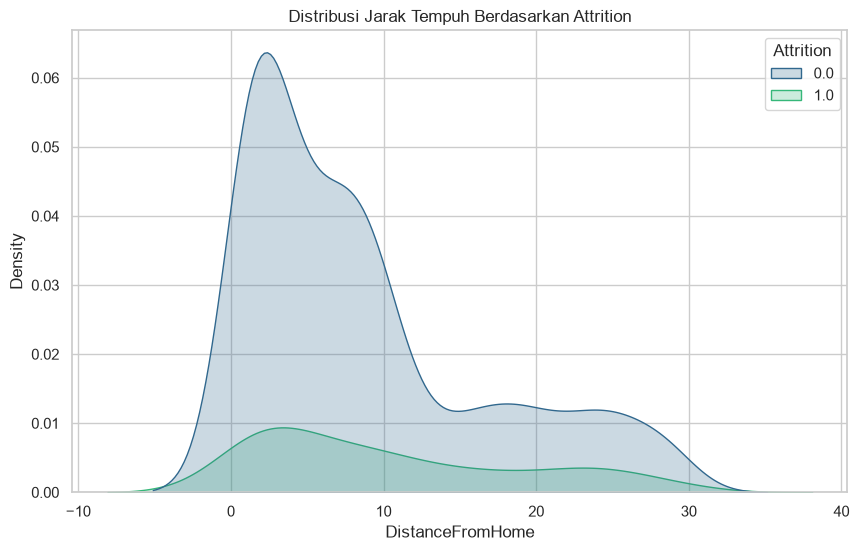

In [5]:
# Perilaku: Hubungan Attrition dengan Jarak Tempuh (DistanceFromHome)
plt.figure(figsize=(10,6))
sns.kdeplot(data=data, x='DistanceFromHome', hue='Attrition', fill=True, palette='viridis')
plt.title('Distribusi Jarak Tempuh Berdasarkan Attrition')
plt.show()

## Menjawab Permasalahan Bisnis 3: Evaluasi Stagnasi Karier dan Manajemen
Sejauh mana durasi karyawan dalam peran saat ini (*YearsInCurrentRole*) serta hubungan dengan manajer (*YearsWithCurrManager*) memengaruhi *attrition*.

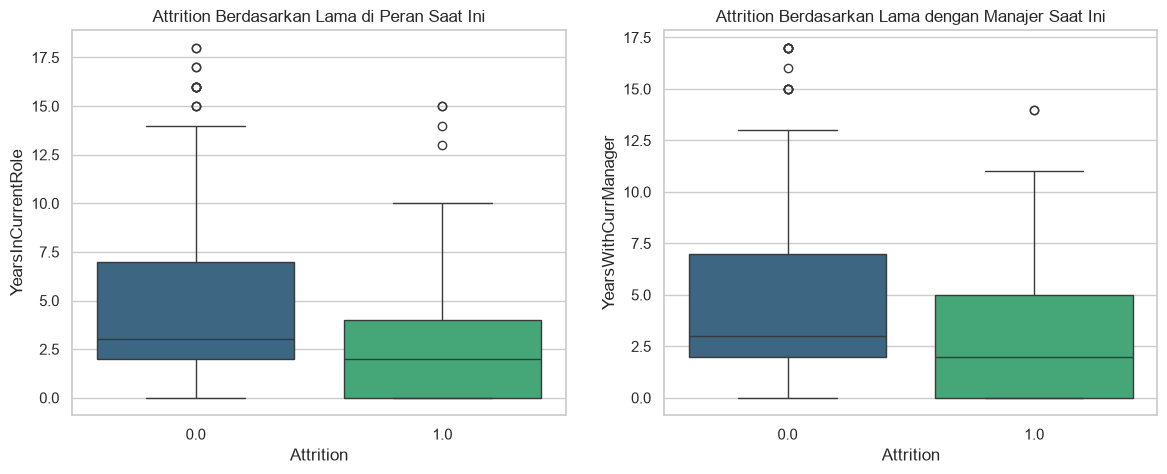

In [6]:
# Stagnasi Karier & Manajemen: YearsInCurrentRole & YearsWithCurrManager
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(data=data, x='Attrition', y='YearsInCurrentRole', palette='viridis', ax=axes[0])
axes[0].set_title('Attrition Berdasarkan Lama di Peran Saat Ini')
sns.boxplot(data=data, x='Attrition', y='YearsWithCurrManager', palette='viridis', ax=axes[1])
axes[1].set_title('Attrition Berdasarkan Lama dengan Manajer Saat Ini')
plt.show()